# Curso Conceitos e Aplicações em Aprendizado de Máquina
***


## Trabalho Prático

### Objetivos de Ensino

Exercitar os seguintes conceitos trabalhados no Curso:

1. Criar virtualenv e realizar a instalação das bibliotecas necessárias para o trabalho. (OK) 
2. Coletar dados.  
3. Analisar e realizar tratamento de dados.  
4. Criar algoritmo de Machine Learning.  
5. Avaliar os resultados.  
6. Utilizar o conhecimento teórico ministrado nas videoaulas.  


# Importando as Bilbiotecas
***

In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.simplefilter('ignore')

import seaborn as sns
import matplotlib.pyplot as plt

# Coletando e tratando os DADOS
***

In [24]:
# Coletando os dados
df_carros = pd.read_csv('./dataset/cars_efficient.csv',
           sep=',',
            encoding='utf-8-sig'
           )

In [25]:
# Tamanho dos dados
df_carros.shape

(261, 9)

In [26]:
# Informações
df_carros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           261 non-null    float64
 1   cylinders     261 non-null    int64  
 2   cubicinches   259 non-null    float64
 3   hp            261 non-null    int64  
 4   weightlbs     258 non-null    float64
 5   time-to-60    261 non-null    int64  
 6   year          261 non-null    int64  
 7   brand         261 non-null    object 
 8   is_efficient  261 non-null    int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 18.5+ KB


In [27]:
# Identificar dados duplicados
# df_carros.duplicated().any()
df_carros.duplicated().sum()
# df_carros[df_carros.duplicated()]

np.int64(0)

In [28]:
# Media da coluna mpg
df_carros["mpg"].mean()

np.float64(23.144827586206894)

In [29]:
# Crie o algoritmo de árvore de decisão com apenas o parâmetro de random_state=42 e responda. Qual a feature de maior importância?
from sklearn.tree import DecisionTreeClassifier

# Separar X e y
X = df_carros.drop("brand", axis=1)   # todas as features exceto a marca
y = df_carros["brand"]

# Criar e treinar o modelo de árvore de decisão
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X, y)

# Importância das features
importancias = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values(by="importance", ascending=False)

importancias


,feature,importance
2,cubicinches,0.484612
4,weightlbs,0.163655
3,hp,0.115157
0,mpg,0.095119
5,time-to-60,0.074602
6,year,0.053678
1,cylinders,0.013178
7,is_efficient,0.000000


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Separar features e target
X = df_carros.drop("brand", axis=1)
y = df_carros["brand"]

# Dividir em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Criar e treinar o modelo de árvore de decisão
modelo = DecisionTreeClassifier(random_state=42, max_depth=7)
modelo.fit(X_train, y_train)

# Fazer previsões
y_pred = modelo.predict(X_test)

# Calcular acurácia
acuracia = accuracy_score(y_test, y_pred)
print("Acurácia do modelo:", acuracia)


Acurácia do modelo: 0.759493670886076


In [31]:
# Identificar os dados ausentes
df_carros.isnull().sum()


mpg             0
cylinders       0
cubicinches     2
hp              0
weightlbs       3
time-to-60      0
year            0
brand           0
is_efficient    0
dtype: int64

In [32]:
# Descrição dos dados
df_carros.describe()

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,is_efficient
count,261.000000,261.000000,259.000000,261.000000,258.000000,261.000000,261.000000,261.000000
mean,23.144828,5.590038,200.918919,106.360153,3009.833333,15.547893,1976.819923,0.379310
std,7.823570,1.733310,109.258305,40.499959,854.039019,2.910625,3.637696,0.486148
min,10.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,1971.000000,0.000000
25%,16.900000,4.000000,99.500000,75.000000,2248.000000,14.000000,1974.000000,0.000000
50%,22.000000,6.000000,156.000000,95.000000,2867.500000,16.000000,1977.000000,0.000000
75%,28.800000,8.000000,303.000000,138.000000,3670.000000,17.000000,1980.000000,1.000000
max,46.600000,8.000000,455.000000,230.000000,4997.000000,25.000000,1983.000000,1.000000


In [33]:
# Contando as Brand
df_carros['brand'].value_counts()


brand
US.        162
Japan.      51
Europe.     48
Name: count, dtype: int64

# Visualizar os dados em um Grafico
***

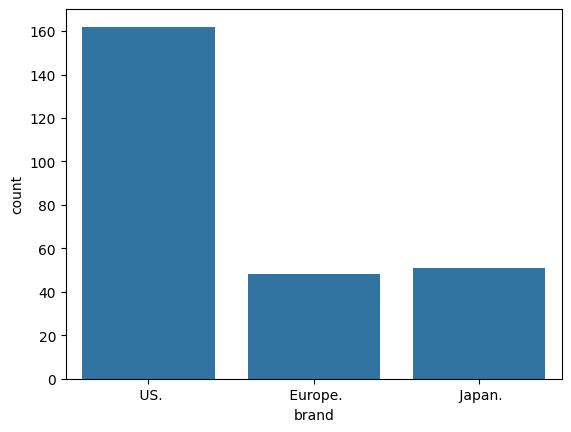

In [34]:
sns.countplot(x="brand", data=df_carros)
plt.show()

# Regras do Enunciado
***

In [35]:
# Numéricos → excluir registros
df_carros = df_carros.dropna(subset=["mpg","cylinders","cubicinches","hp","weightlbs","time-to-60","year"])

In [36]:
# Categóricos → preencher com a moda
for col in ["brand","is_efficient"]:
    df_carros[col] = df_carros[col].fillna(df_carros[col].mode()[0])

# Criar o modelo de Árvore de Decisão
***

In [37]:
# Separar variáveis independentes (X) e dependente (y)
X_dados = df_carros.drop(columns=["brand"])
y_dados = df_carros["brand"]


In [38]:
# Dividir em treino (70%) e teste (30%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_dados, y_dados, test_size=0.3, random_state=42
)


# Treinar a árvore
***

In [43]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# --- Bloco de Geração de Dados (apenas para o exemplo ser funcional) ---
# Em seu código real, você já terá X_train, y_train, etc.
X, y = make_classification(n_samples=1000, n_features=20, n_informative=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# --- Fim do Bloco de Geração de Dados ---


# 1. Armazenar os resultados em uma lista de dicionários
resultados_lista = []

for depth in range(1, 21): # Aumentado para 20 para incluir o 20
    model = DecisionTreeClassifier(random_state=42, max_depth=depth)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados_lista.append({"Profundidade": depth, "Acurácia": acc})

# 2. Converter a lista em um DataFrame do pandas
df_resultados = pd.DataFrame(resultados_lista)

# 3. Encontrar a melhor e a pior profundidade usando o DataFrame
melhor_resultado = df_resultados.loc[df_resultados['Acurácia'].idxmax()]
pior_resultado = df_resultados.loc[df_resultados['Acurácia'].idxmin()]

# 4. Exibir os resultados de forma organizada
print("### Tabela de Resultados por Profundidade da Árvore ###")
print(df_resultados.to_string(index=False))

print("\n" + "="*50 + "\n")

print("### Resumo da Análise ###")
print(f"Melhor Profundidade: {int(melhor_resultado['Profundidade'])} com Acurácia = {melhor_resultado['Acurácia']:.4f}")
print(f"Pior Profundidade:   {int(pior_resultado['Profundidade'])} com Acurácia = {pior_resultado['Acurácia']:.4f}")

### Tabela de Resultados por Profundidade da Árvore ###
 Profundidade  Acurácia
            1  0.763333
            2  0.833333
            3  0.880000
            4  0.850000
            5  0.866667
            6  0.883333
            7  0.886667
            8  0.876667
            9  0.883333
           10  0.886667
           11  0.886667
           12  0.886667
           13  0.886667
           14  0.886667
           15  0.886667
           16  0.886667
           17  0.886667
           18  0.886667
           19  0.886667
           20  0.886667


### Resumo da Análise ###
Melhor Profundidade: 7 com Acurácia = 0.8867
Pior Profundidade:   1 com Acurácia = 0.7633


# Avaliar os resultados
***

In [21]:
y_pred = model.predict(X_test)

In [22]:
# Avaliar acurácia e métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))


Acurácia: 0.7662337662337663

Relatório de Classificação:
               precision    recall  f1-score   support

     Europe.       0.75      0.64      0.69        14
      Japan.       0.67      0.50      0.57        16
         US.       0.79      0.89      0.84        47

    accuracy                           0.77        77
   macro avg       0.74      0.68      0.70        77
weighted avg       0.76      0.77      0.76        77


Matriz de Confusão:
 [[ 9  1  4]
 [ 1  8  7]
 [ 2  3 42]]


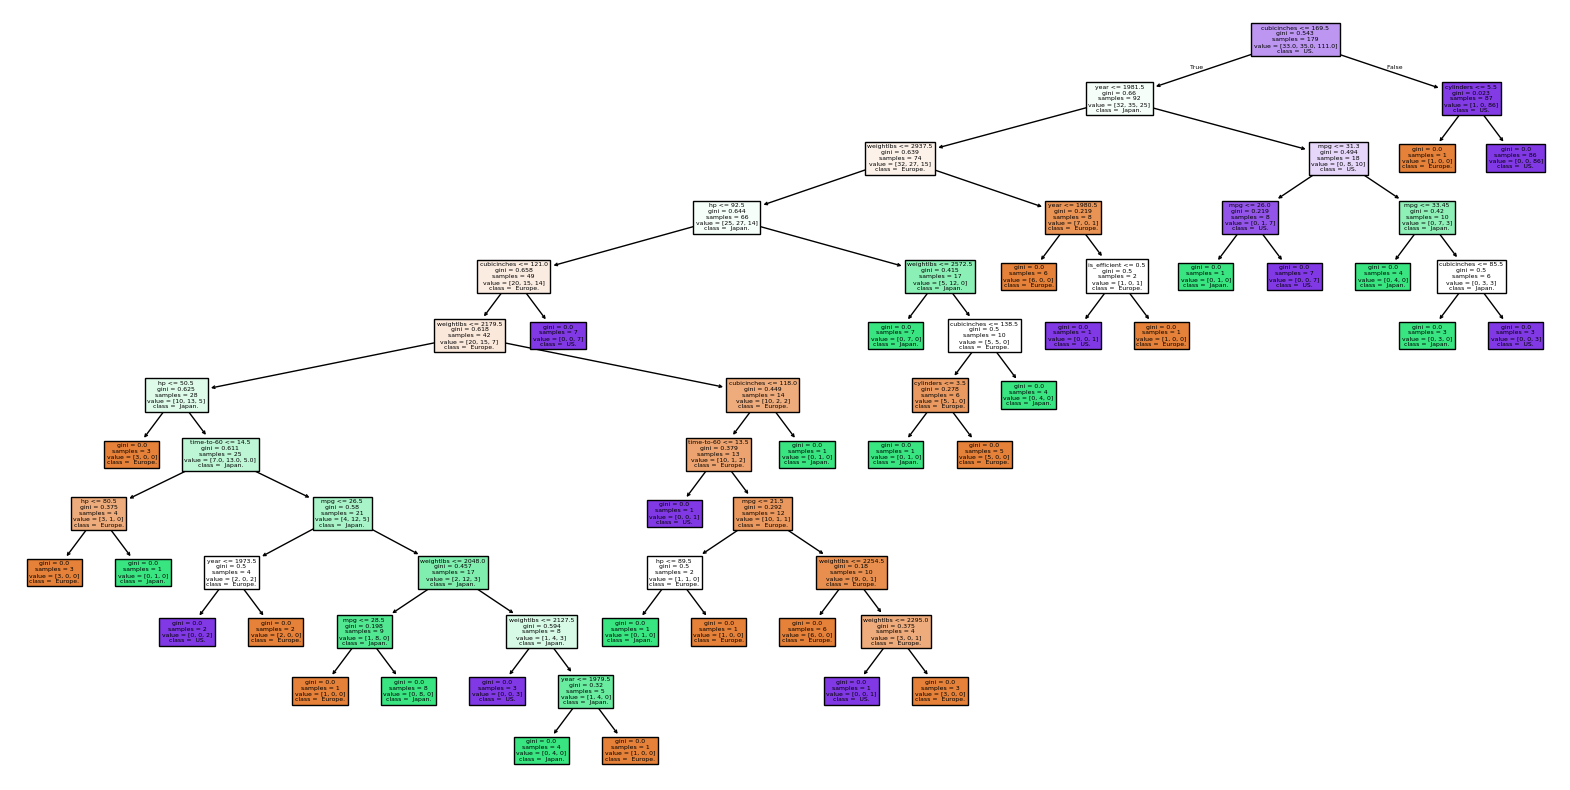

In [24]:
# Visualizar a arvore
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(model, filled=True, feature_names=X_dados.columns, class_names=model.classes_)
plt.show()
